In [1]:
# We start by importing all the necessary packages
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math
from Python_files import time_integration_functions as TST
from Python_files import TLM_Test as TT
from Python_files import ETLM as ETLMC
from Python_files import LETLM_ensemble as LETLMC
from Python_files import IETLM_ensemble as IETLMC
from Python_files import GETLM as GETLMC
from Python_files import GETLM_experiment_neat as GEN

In [2]:
# we now define stuff as required
model = TST.CN_L96

N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.1 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)

perturbation_size = 10**(-7)
ensemble_size = 15
num_steps = 15
trials = 30
LETLM_stencil = [[0], [-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5]]
IETLM_stencil = [[-2,-1,0,1], [-2,-1,0,1]]
GETLM_stencil = [[-2,-1,0,1],[-2,-1,0,1],[0]]

x_values = np.arange(1, num_steps+1)  


In [3]:
LETLM_TT_result, IETLM_TT_result, GETLM_1_TT_result, GETLM_2_TT_result, GETLM_3_TT_result, GETLM_4_TT_result = GEN.GETLM_experiment(model, model_parameters, perturbation_size, ensemble_size, num_steps, LETLM_stencil, IETLM_stencil, GETLM_stencil)

/Users/imilesfine/PhD_Work/2026/GETLM_L96/Python_files/TLM_Test.py:18: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4483.)
  TLM_test_result = torch.sqrt((alpha.T @ alpha)/(beta.T @ beta))


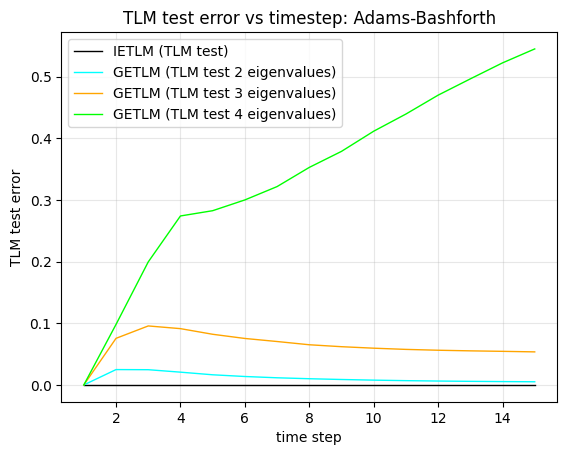

<Figure size 640x480 with 0 Axes>

In [4]:
plt.plot(x_values, IETLM_TT_result, label='IETLM (TLM test)', color='black', linewidth=1)
# plt.plot(x_values, LETLM_TT_result, label='LETLM (TLM test)', color='blue', linewidth=1)

# plt.plot(x_values, GETLM_1_TT_result, label='GETLM (TLM test 1 eigenvalue)', color='purple', linewidth=1)
plt.plot(x_values, GETLM_2_TT_result, label='GETLM (TLM test 2 eigenvalues)', color='aqua', linewidth=1)
plt.plot(x_values, GETLM_3_TT_result, label='GETLM (TLM test 3 eigenvalues)', color='orange', linewidth=1)
plt.plot(x_values, GETLM_4_TT_result, label='GETLM (TLM test 4 eigenvalues)', color='lime', linewidth=1)

plt.title("TLM test error vs timestep: Adams-Bashforth")
plt.xlabel("time step")
plt.ylabel("TLM test error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop
plt.clf()

In [5]:

LETLM_TT_result, IETLM_TT_result, GETLM_1_TT_result, GETLM_2_TT_result, GETLM_3_TT_result, GETLM_4_TT_result = GEN.GETLM_experiment_trials(model, model_parameters, perturbation_size, ensemble_size, num_steps, trials, LETLM_stencil, IETLM_stencil, GETLM_stencil)
print(LETLM_TT_result.shape)

torch.Size([30, 15])


100%|██████████| 30/30 [00:30<00:00,  1.02s/it]

torch.Size([15])
torch.Size([15])



/Users/imilesfine/PhD_Work/2026/GETLM_L96/Python_files/GETLM_experiment_neat.py:331: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  LETLM_mean = torch.mean(torch.tensor(LETLM_TT_result_large), dim = 0)
/Users/imilesfine/PhD_Work/2026/GETLM_L96/Python_files/GETLM_experiment_neat.py:332: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  IETLM_mean = torch.mean(torch.tensor(IETLM_TT_result_large), dim = 0)
/Users/imilesfine/PhD_Work/2026/GETLM_L96/Python_files/GETLM_experiment_neat.py:333: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  GETLM_1_me

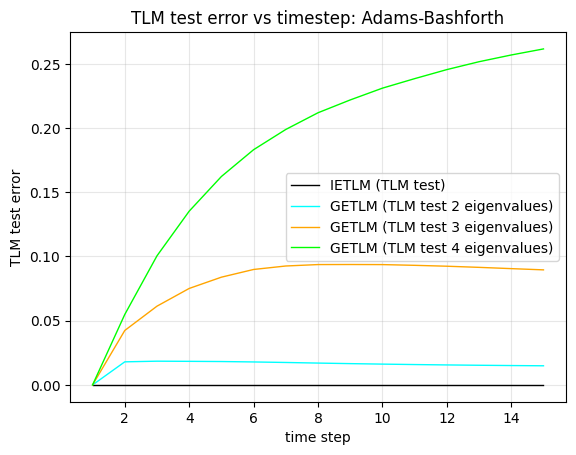

<Figure size 640x480 with 0 Axes>

In [7]:
plt.plot(x_values, IETLM_TT_result, label='IETLM (TLM test)', color='black', linewidth=1)
# plt.plot(x_values, LETLM_TT_result, label='LETLM (TLM test)', color='blue', linewidth=1)

# plt.plot(x_values, GETLM_1_TT_result, label='GETLM (TLM test 1 eigenvalue)', color='purple', linewidth=1)
plt.plot(x_values, GETLM_2_TT_result, label='GETLM (TLM test 2 eigenvalues)', color='aqua', linewidth=1)
plt.plot(x_values, GETLM_3_TT_result, label='GETLM (TLM test 3 eigenvalues)', color='orange', linewidth=1)
plt.plot(x_values, GETLM_4_TT_result, label='GETLM (TLM test 4 eigenvalues)', color='lime', linewidth=1)

plt.title("TLM test error vs timestep: Adams-Bashforth")
plt.xlabel("time step")
plt.ylabel("TLM test error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop
plt.clf()